## Setup

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optuna
from scipy.stats import gaussian_kde

mpl.rcParams["figure.dpi"] = 300

LAUNCH_DIR = "out/flat_conv"

/mnt/servicesdata/lcotti/csi-vae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
studies_dir = Path("../") / LAUNCH_DIR
studies_files = [f.name for f in studies_dir.iterdir()]
studies = [
    optuna.load_study(study_name=study.split(".")[0], storage=f"sqlite:///{studies_dir / study}").trials_dataframe()
    for study in studies_files
]

In [4]:
studies[0].head()

,number,value,datetime_start,datetime_complete,duration,params_batch_size_exp,params_conv_layers_spec,params_kl_max,params_lr,params_n_fusion_layers,user_attrs_accuracies,user_attrs_accuracy_p25,user_attrs_accuracy_p75,state
0,0,0.893750,2026-03-26 14:13:38.325559,2026-03-26 14:24:17.322477,0 days 00:10:38.996918,5,0,17.254717,0.003575,3,"{'1467609230': 0.7791666666666667, '47521683':...",0.828125,0.904167,COMPLETE
1,1,0.793750,2026-03-26 14:24:17.476591,2026-03-26 14:32:55.178004,0 days 00:08:37.701413,5,1,6.054366,0.019030,3,"{'448960789': 0.8875, '1467609230': 0.79375, '...",0.770833,0.842708,COMPLETE
2,2,0.925000,2026-03-26 14:32:55.306828,2026-03-26 14:41:33.195046,0 days 00:08:37.888218,6,0,1.732267,0.001856,1,"{'448960789': 0.8729166666666667, '1617185032'...",0.885417,0.952083,COMPLETE
3,3,0.910417,2026-03-26 14:41:33.319346,2026-03-26 14:52:42.072153,0 days 00:11:08.752807,6,1,2.399324,0.001607,2,"{'1617185032': 0.91875, '1511836286': 0.910416...",0.894792,0.916667,COMPLETE
4,4,NaN,2026-03-26 14:52:42.174894,2026-03-26 15:01:51.613330,0 days 00:09:09.438436,7,2,1.149300,0.007500,2,NaN,NaN,NaN,FAIL



## Plots

### Trial Outcomes

n_gaussians: 1


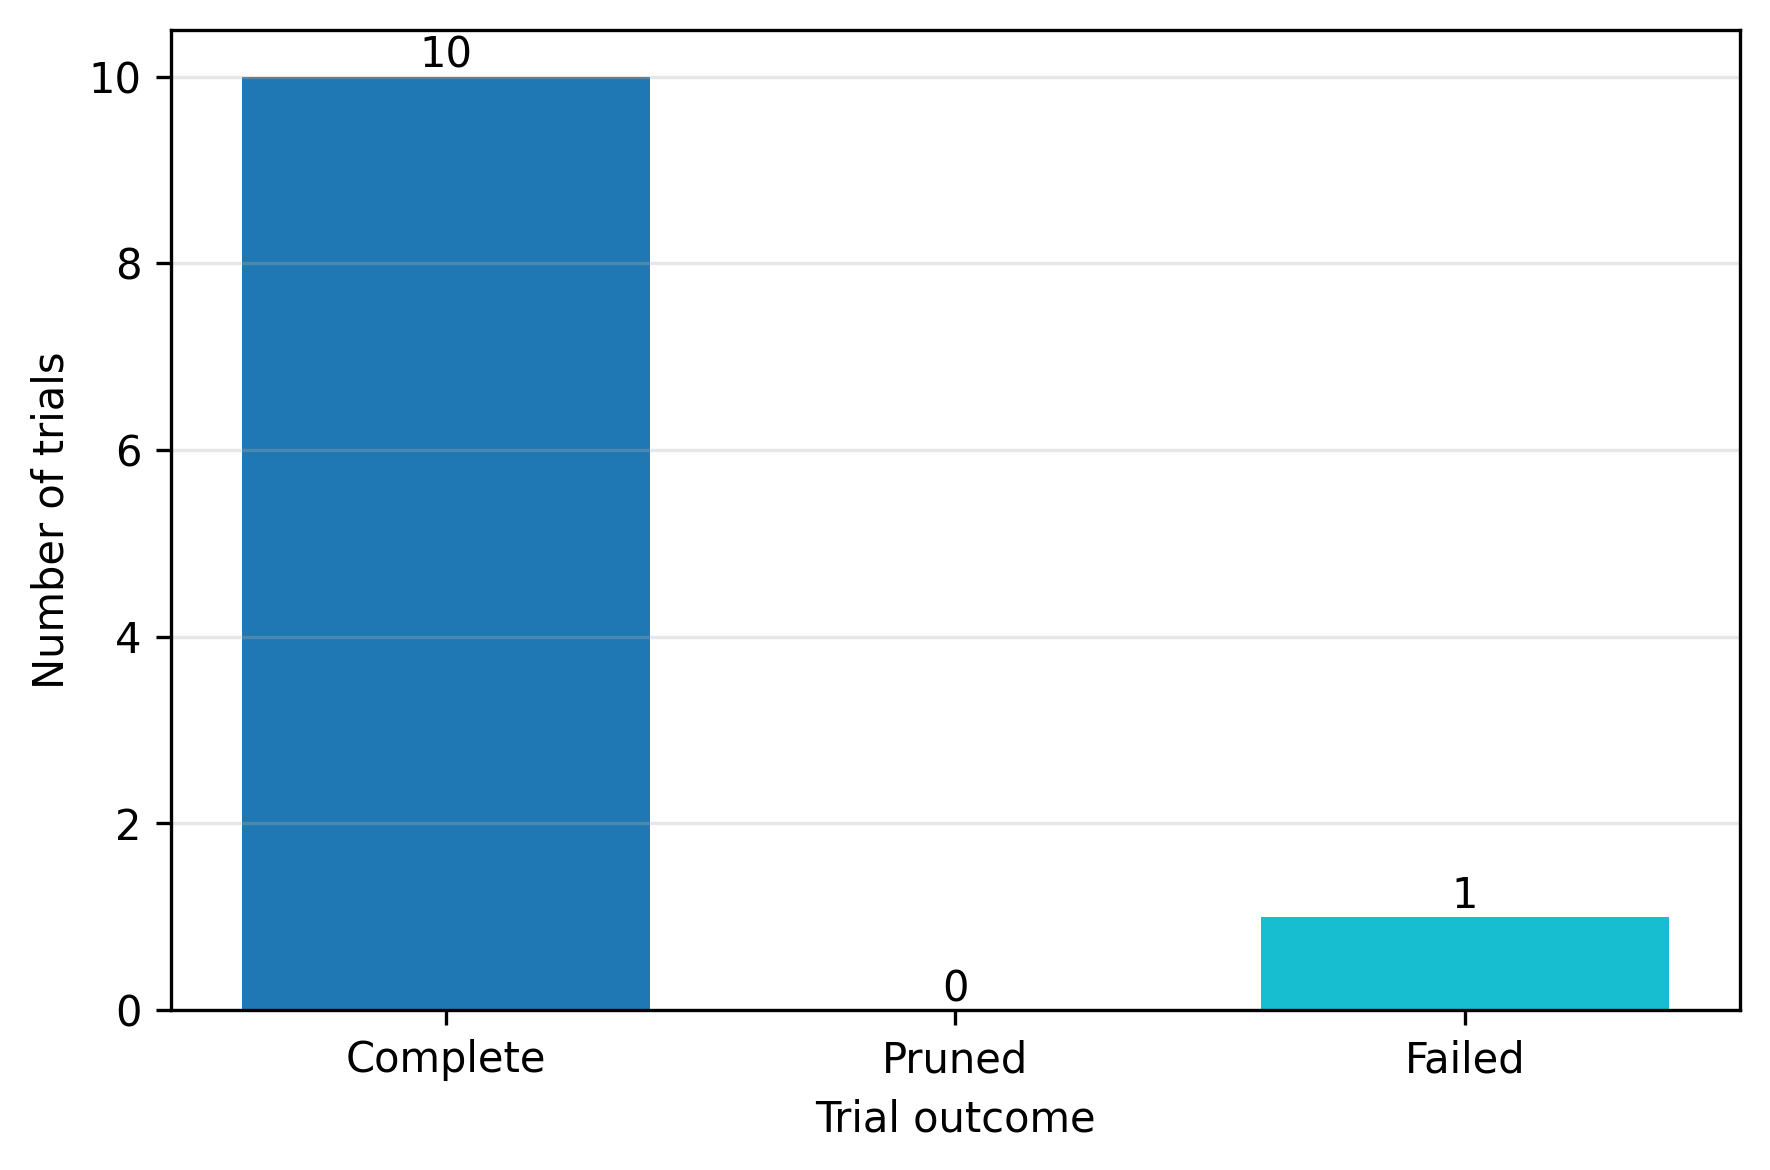

n_gaussians: 2


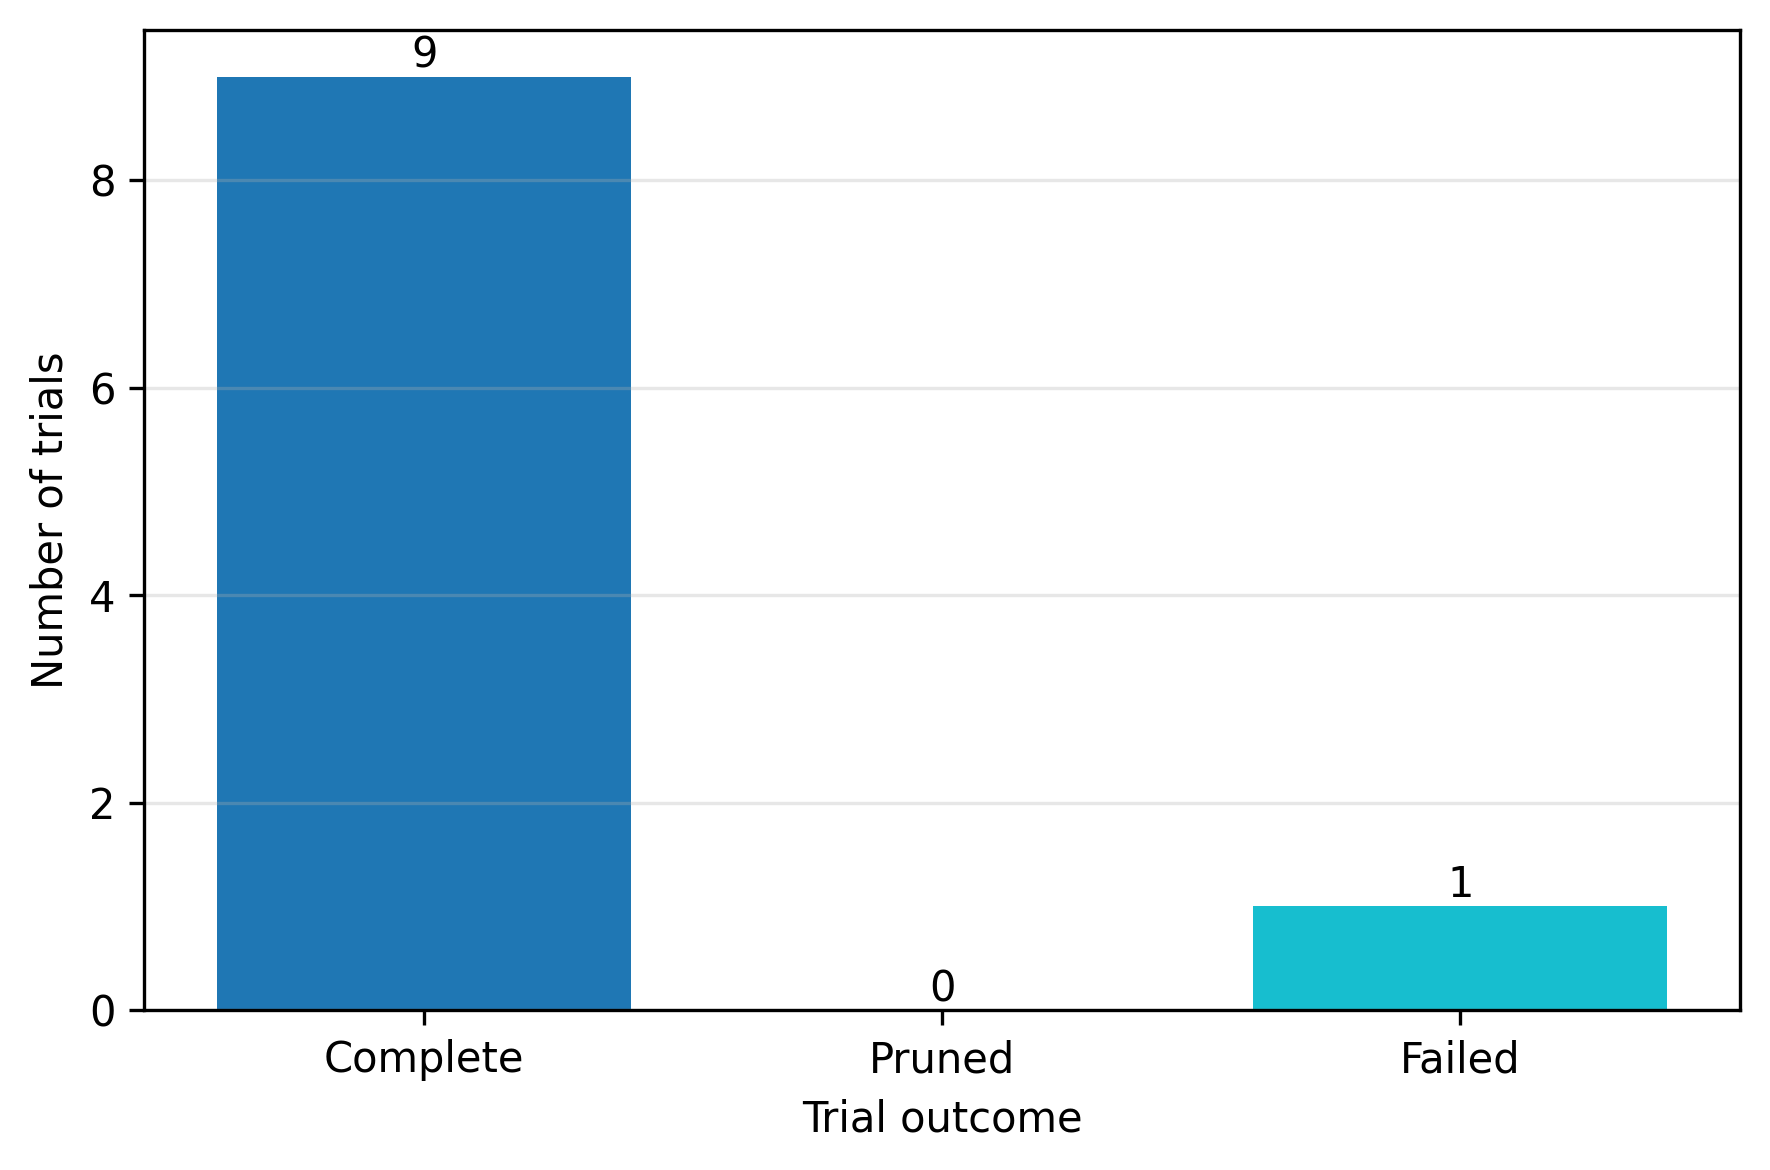

n_gaussians: 3


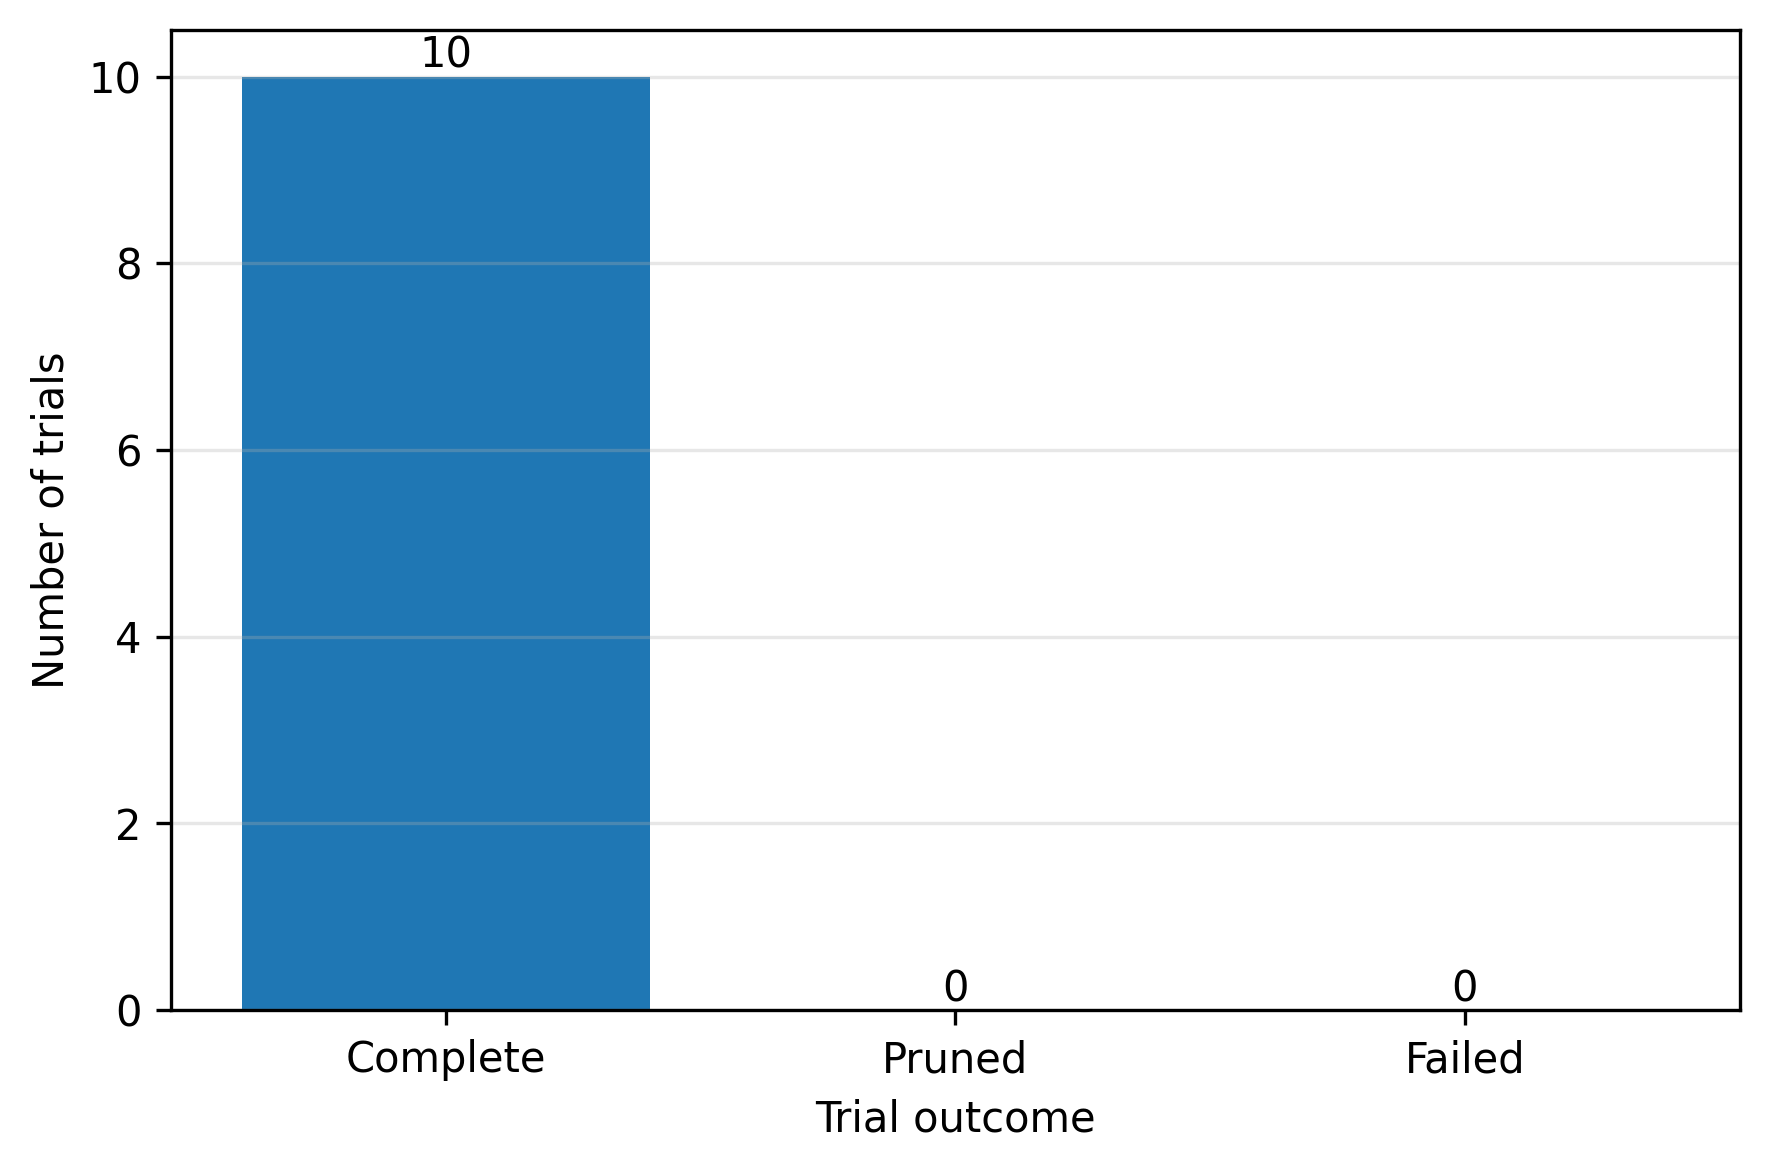

n_gaussians: 4


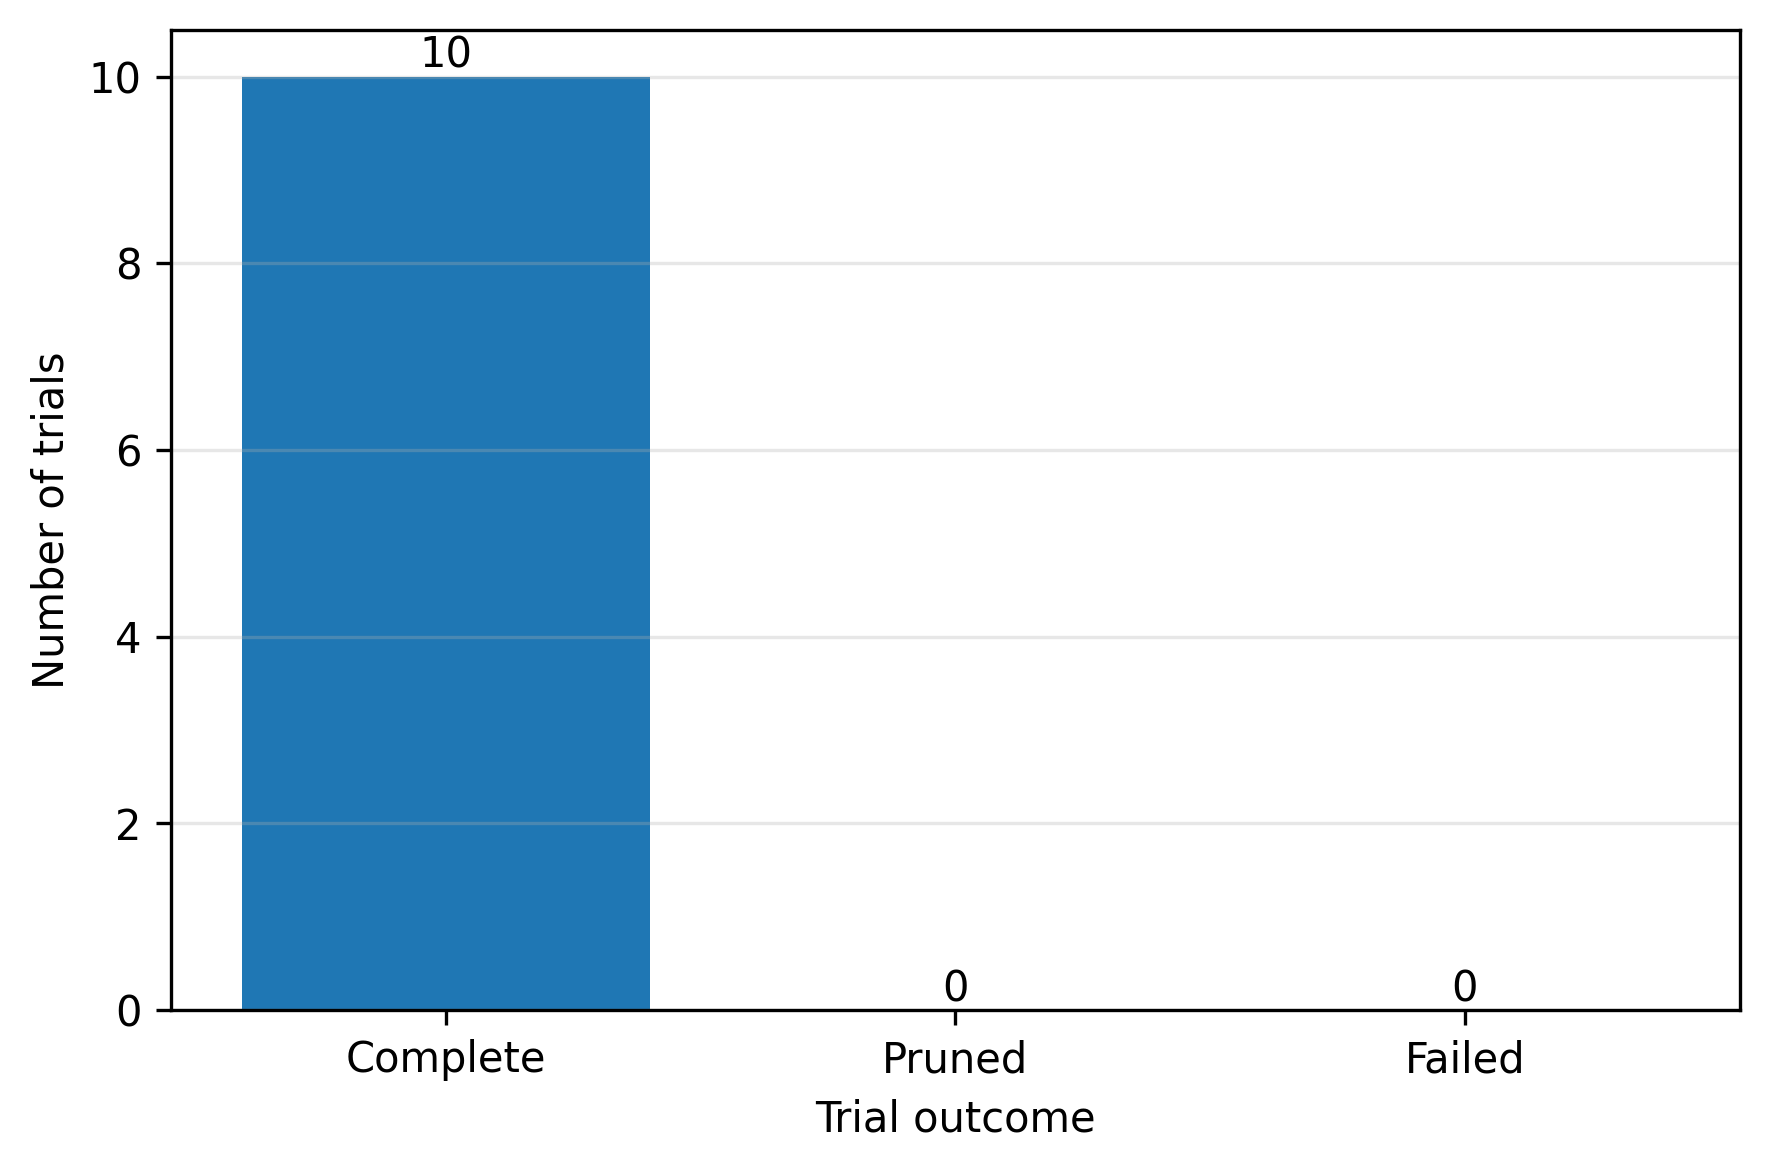

In [7]:
for i, study in enumerate(studies):
    print(f"n_gaussians: {i+1}")
    counts = {
        "Complete": study[study["state"] == "COMPLETE"].shape[0],
        "Pruned": study[study["state"] == "PRUNED"].shape[0],
        "Failed": study[study["state"] == "FAIL"].shape[0],
    }

    plt.figure(figsize=(6, 4))
    colors = plt.colormaps["tab10"](np.linspace(0, 1, len(counts)))
    bars = plt.bar(list(counts.keys()), list(counts.values()), color=colors)
    plt.xlabel("Trial outcome")
    plt.ylabel("Number of trials")

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, h, f"{int(h)}", ha="center", va="bottom")

    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

### Accuracy Distribution

n_gaussians: 1


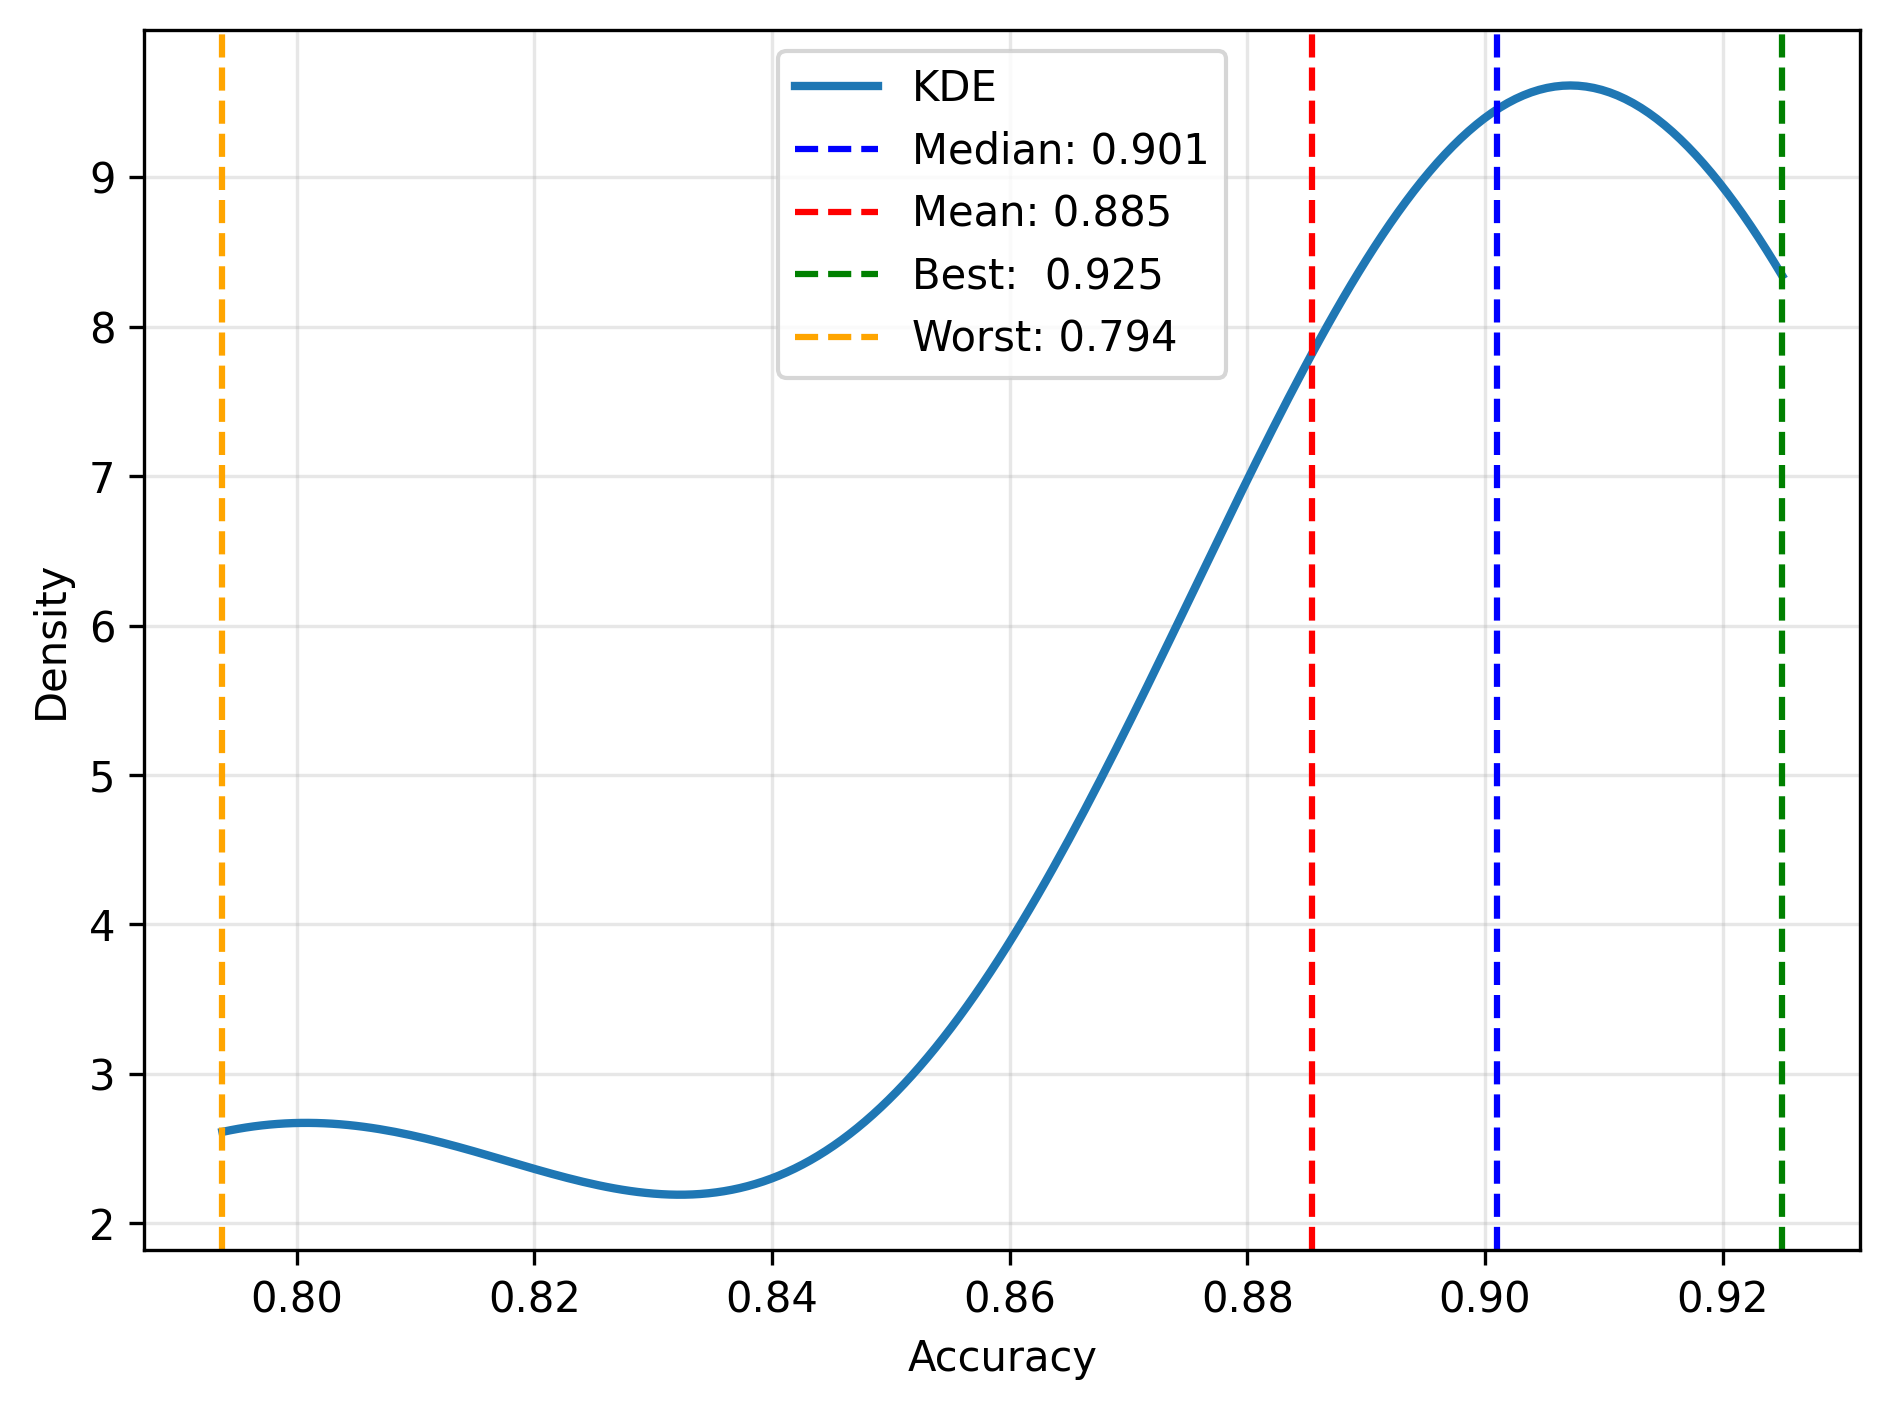

n_gaussians: 2


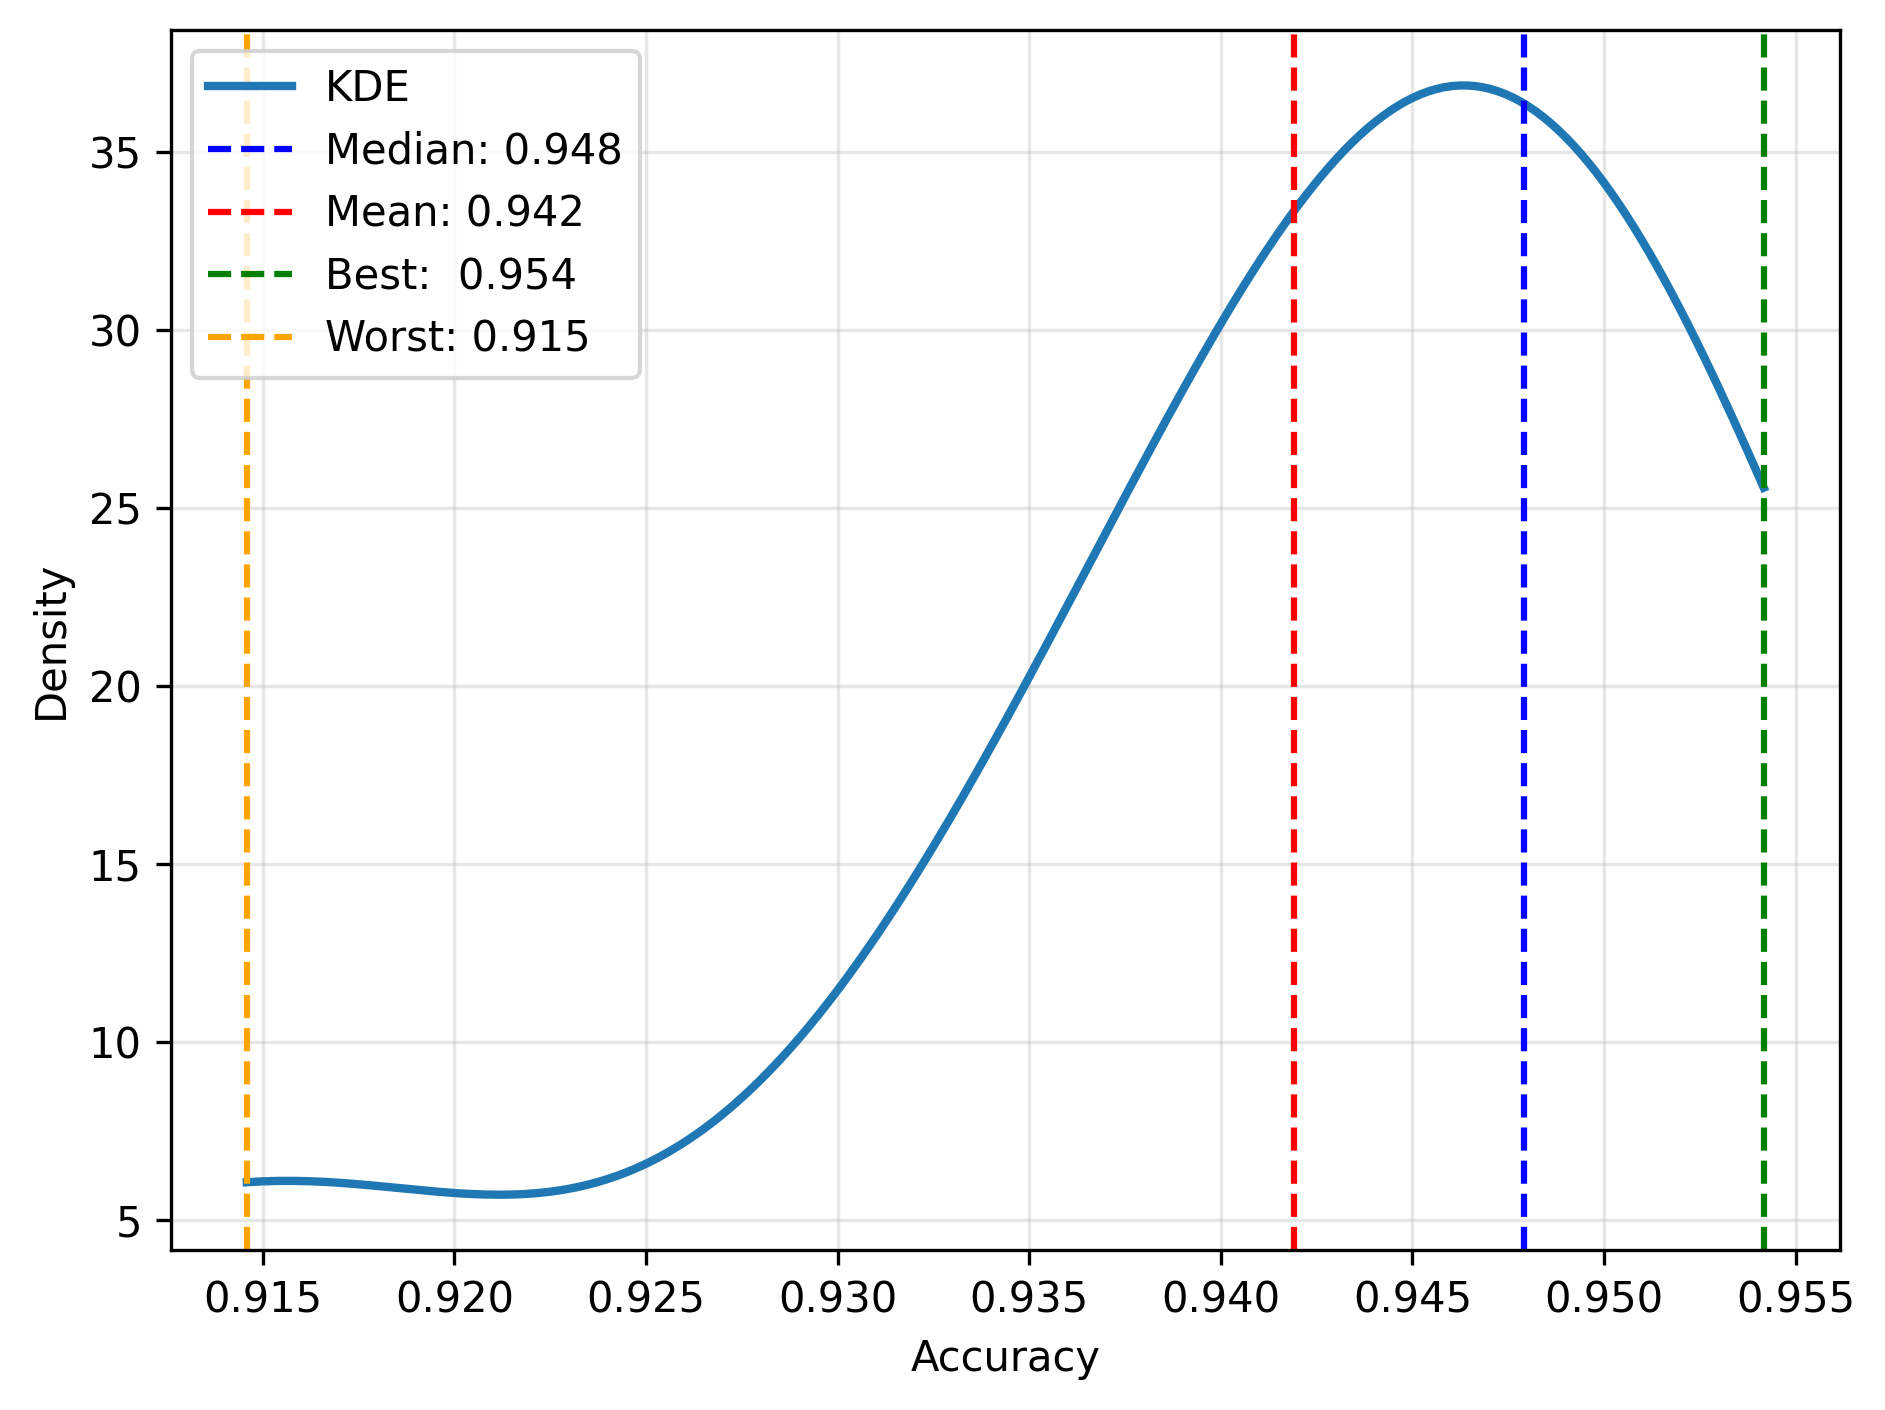

n_gaussians: 3


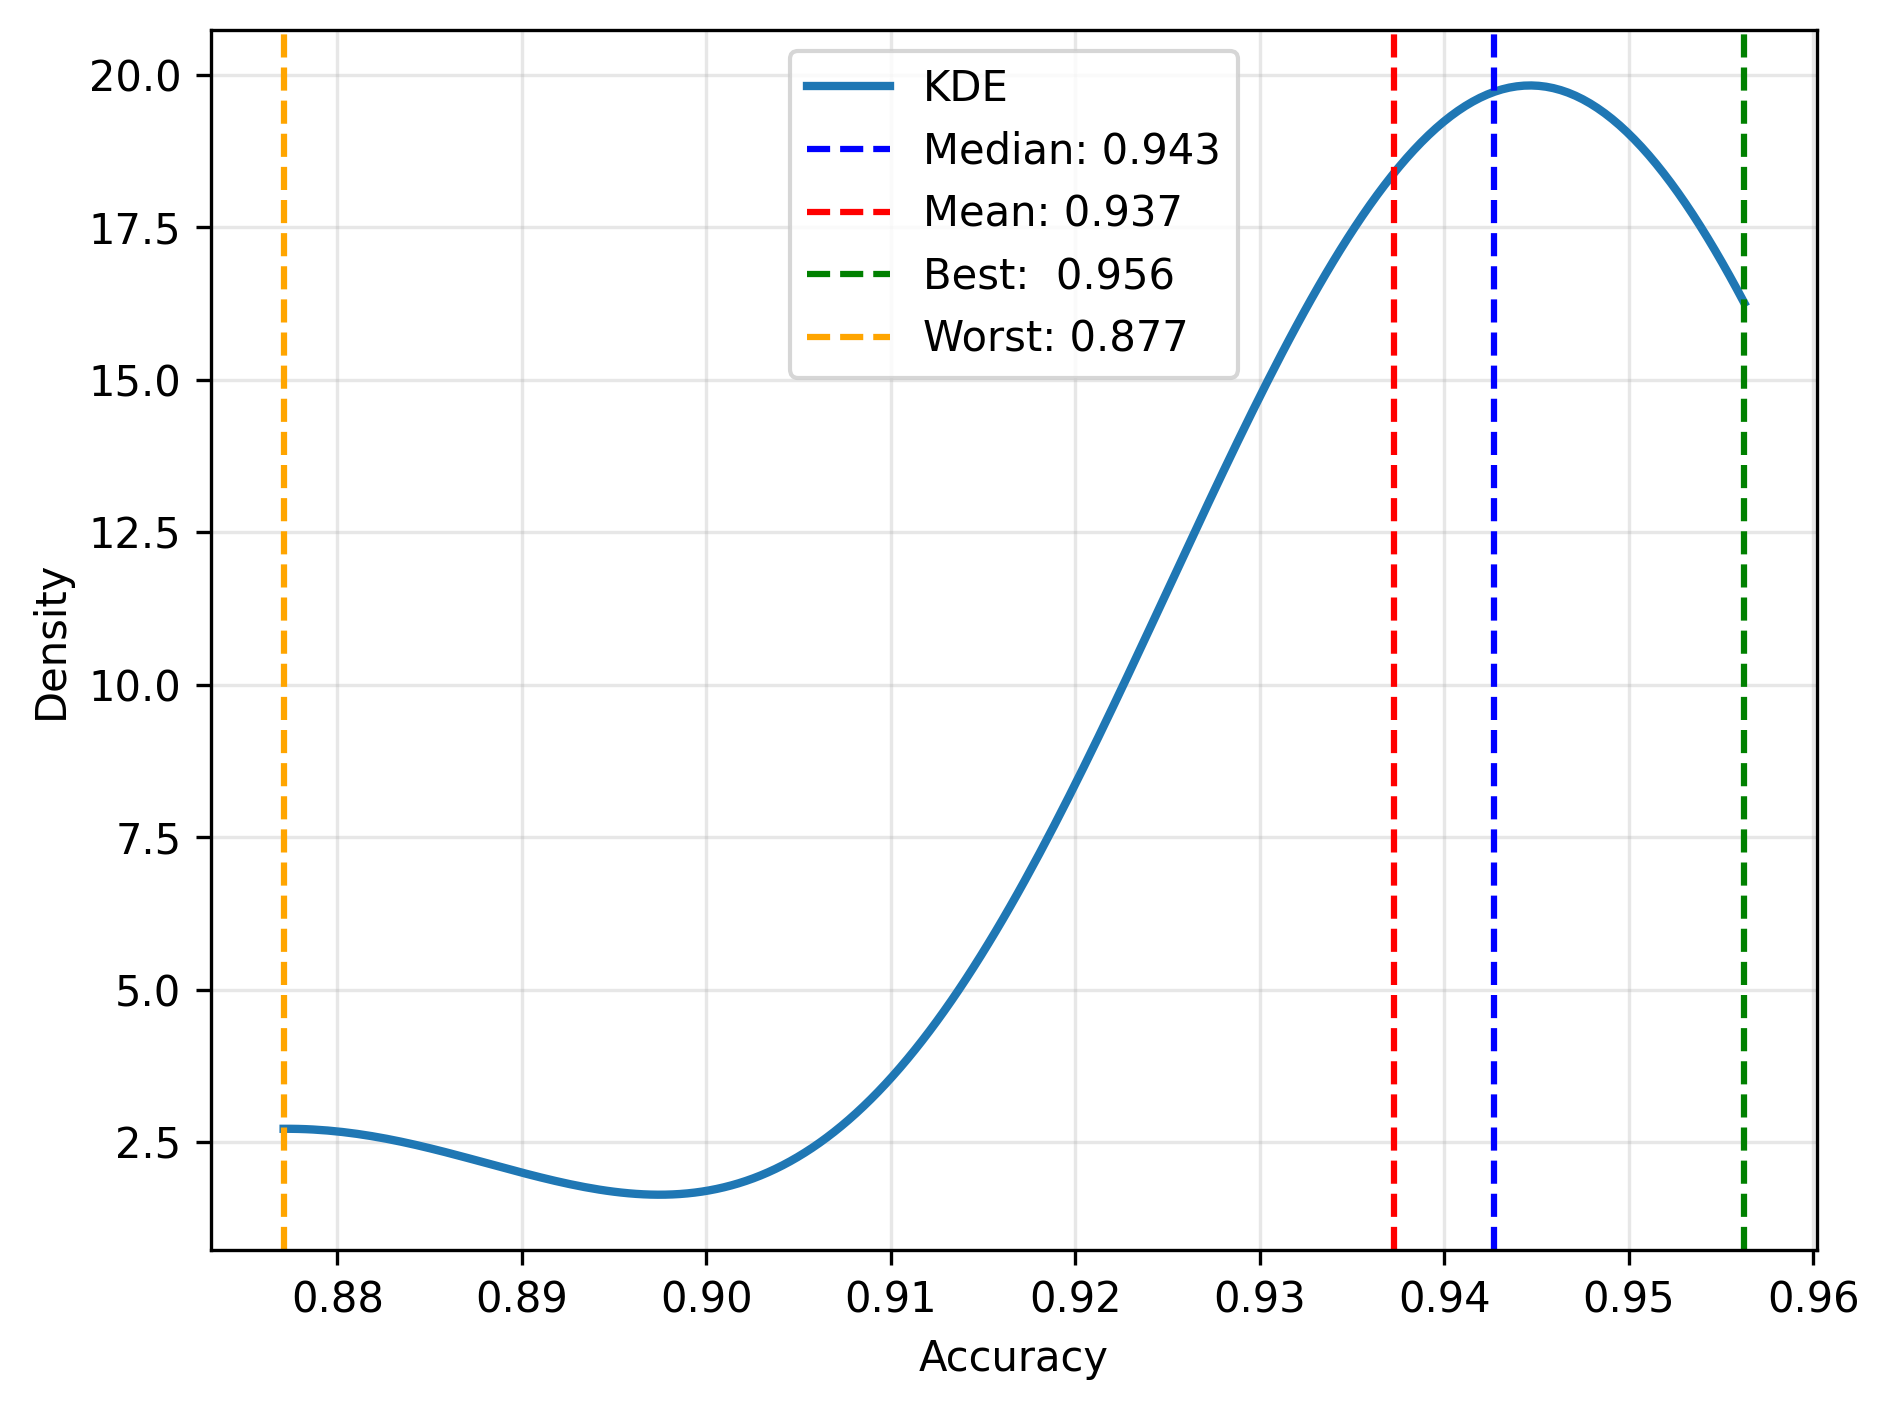

n_gaussians: 4


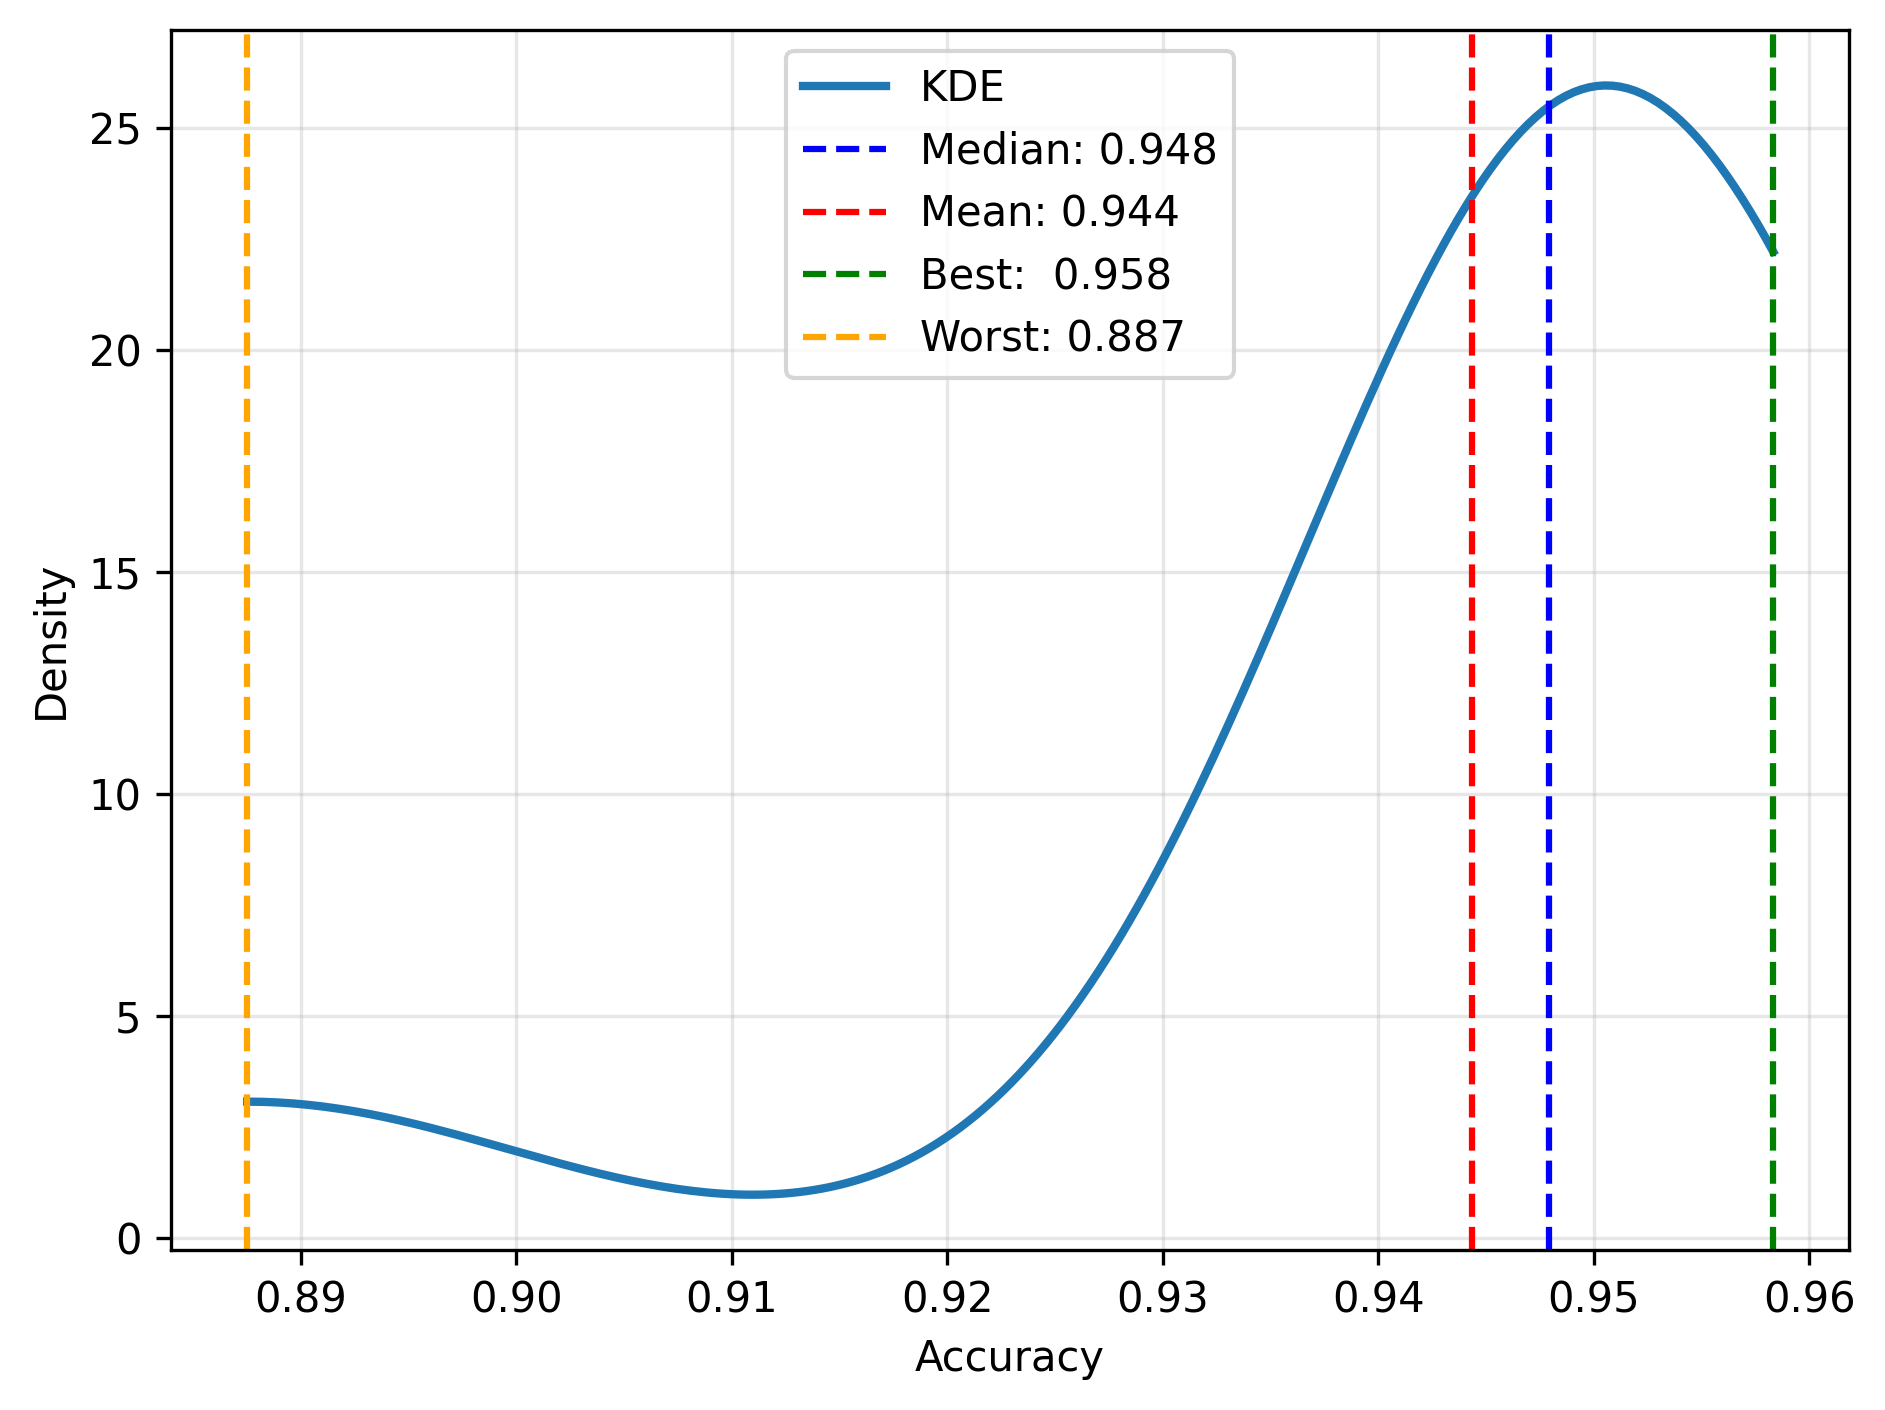

In [8]:
for i, study in enumerate(studies):
    print(f"n_gaussians: {i+1}")
    completed = study[study["state"] == "COMPLETE"]["value"].copy().dropna()

    kde = gaussian_kde(completed)
    x = np.linspace(completed.min(), completed.max(), 200)

    plt.plot(x, kde(x), linewidth=2, label="KDE")
    plt.axvline(completed.median(), color="blue", linestyle="--", label=f"Median: {completed.median():.3f}")
    plt.axvline(completed.mean(), color="red", linestyle="--", label=f"Mean: {completed.mean():.3f}")
    plt.axvline(completed.max(), color="green", linestyle="--", label=f"Best:  {completed.max():.3f}")
    plt.axvline(completed.min(), color="orange", linestyle="--", label=f"Worst: {completed.min():.3f}")
    plt.xlabel("Accuracy")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Hyperparameter Importance

ValueError: zip() argument 2 is shorter than argument 1

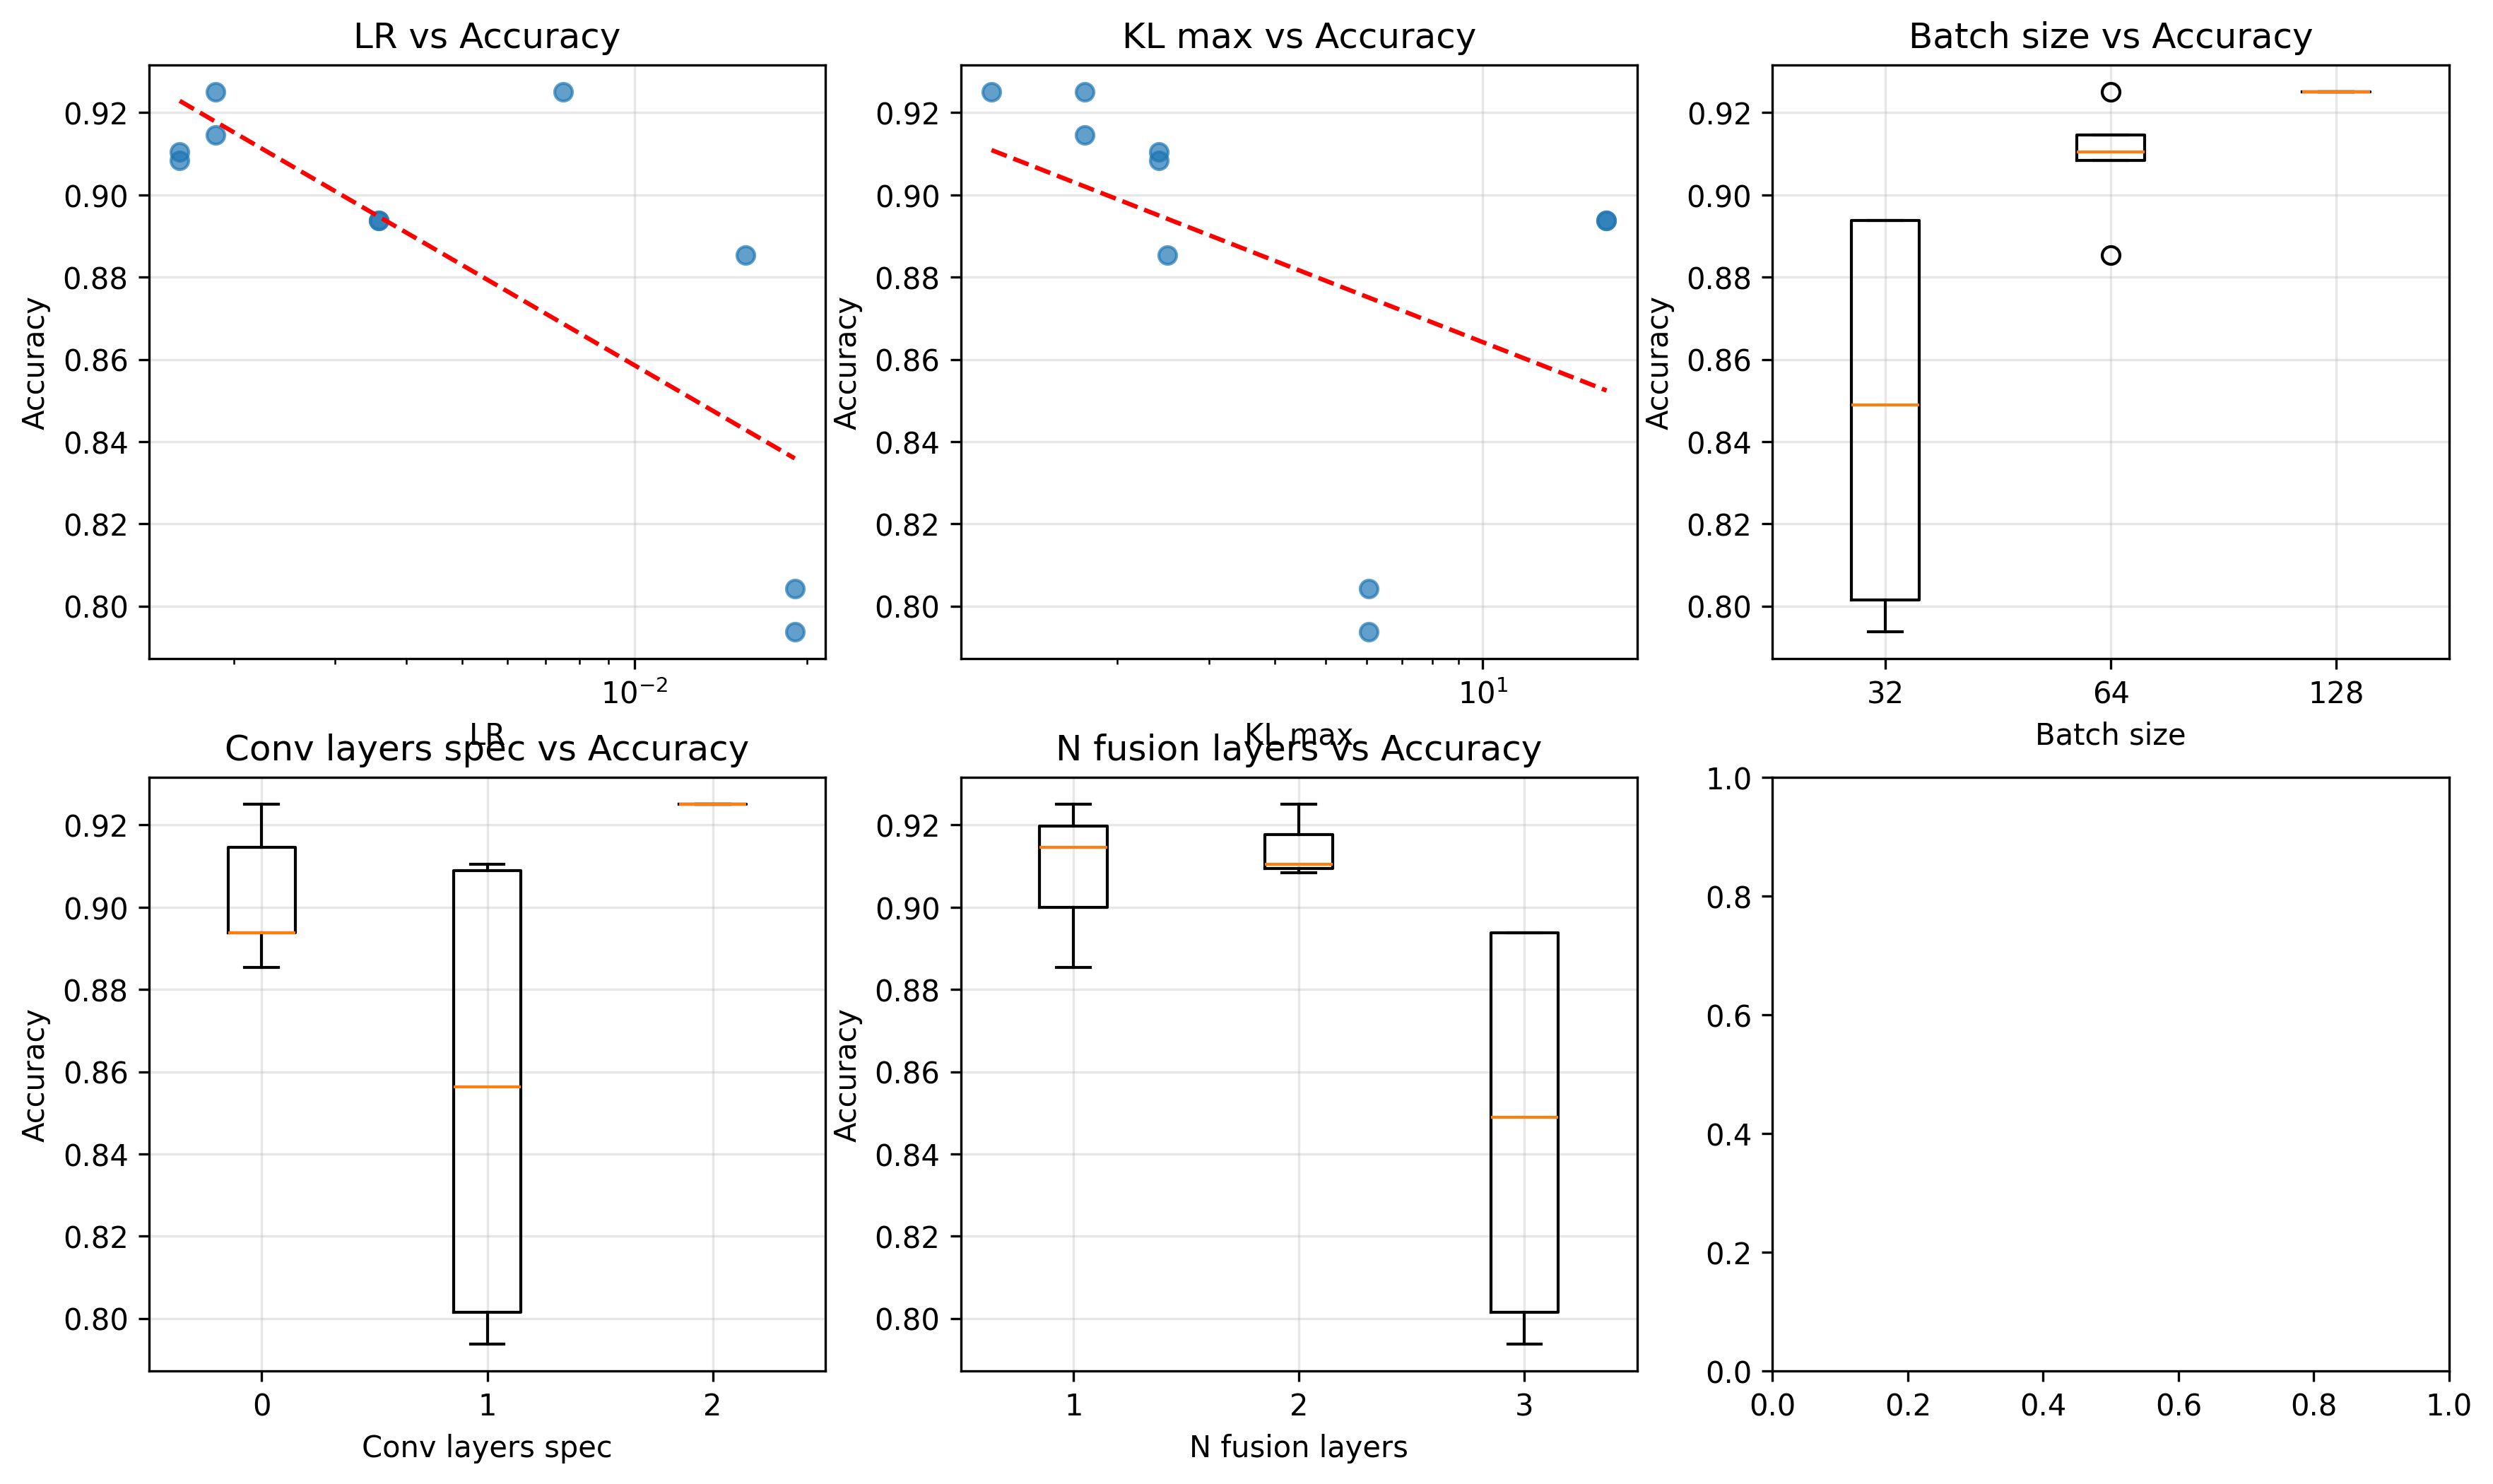

In [10]:
for i, study in enumerate(studies):
    completed = study[study["state"] == "COMPLETE"].copy()
    completed["params_batch_size"] = completed["params_batch_size_exp"].apply(lambda x: 2 ** x)

    params = {
        "params_lr": ("LR", "continuous"),
        "params_kl_max": ("KL max", "continuous"),
        "params_batch_size": ("Batch size", "discrete"),
        "params_conv_layers_spec": ("Conv layers spec", "discrete"),
        "params_n_fusion_layers": ("N fusion layers", "discrete"),
    }

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for ax, (col, (label, kind)) in zip(axes, params.items(), strict=True):
        if kind == "continuous":
            ax.scatter(completed[col], completed["value"], alpha=0.7)
            x = np.log10(completed[col])
            z = np.polyfit(x, completed["value"], 1)
            p = np.poly1d(z)
            x_sorted = np.sort(x)
            ax.plot(10**x_sorted, p(x_sorted), color="red", linewidth=1.5, linestyle="--")
            ax.set_xscale("log")
            ax.set_xlabel(label)
            ax.set_ylabel("Accuracy")
            ax.grid(alpha=0.3)
        else:
            groups = [grp["value"].values for _, grp in completed.groupby(col)]
            labels = sorted(completed[col].unique())
            ax.boxplot(groups, tick_labels=labels)
            ax.set_xlabel(label)
            ax.set_ylabel("Accuracy")
            ax.grid(alpha=0.3)

        ax.set_title(f"{label} vs Accuracy")

    plt.tight_layout()
    plt.show()

KeyError: 'params_batch_size'

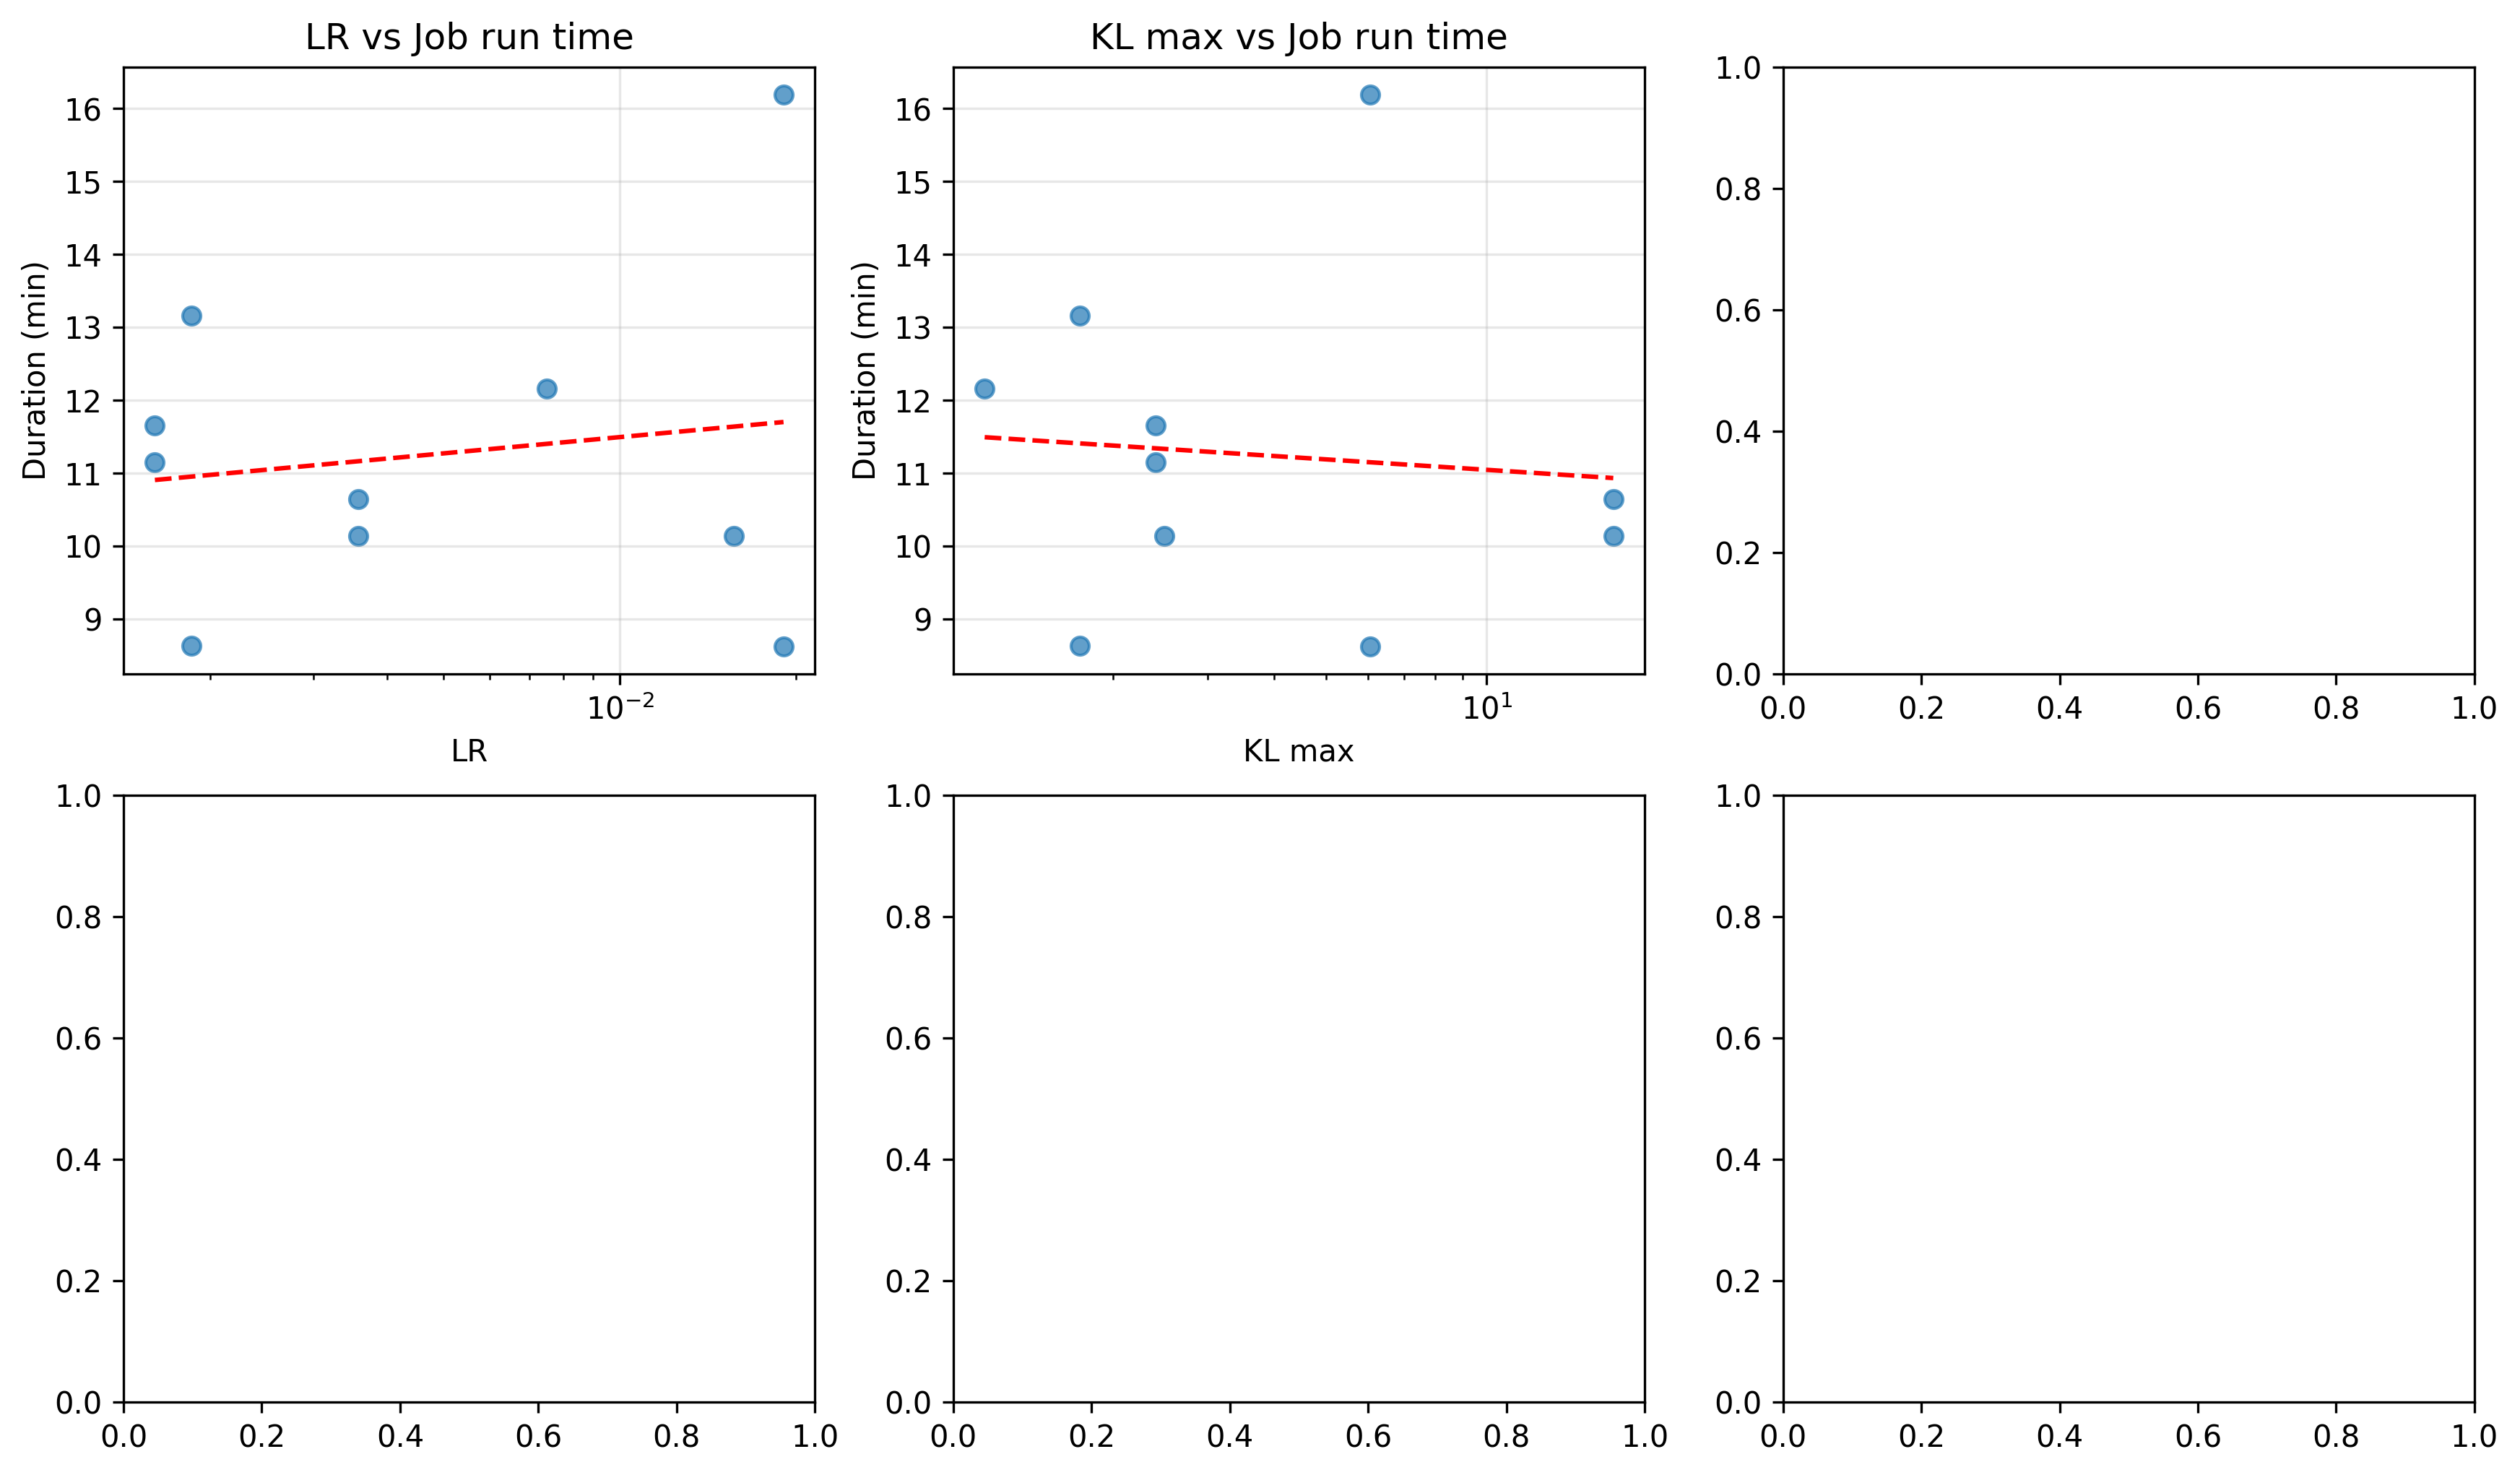

In [11]:
completed = study[study["state"] == "COMPLETE"].copy()
completed["duration_min"] = (
    (completed["datetime_complete"] - completed["datetime_start"])
    .dt.total_seconds() / 60
)

params = {
    "params_lr": ("LR", "continuous"),
    "params_kl_max": ("KL max", "continuous"),
    "params_batch_size": ("Batch size", "discrete"),
    "params_conv_channels": ("Conv channels", "discrete"),
    "params_conv_layers_spec": ("Conv layers spec", "discrete"),
    "params_n_fusion_layers": ("N fusion layers", "discrete"),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (col, (label, kind)) in zip(axes, params.items(), strict=True):
    if kind == "continuous":
        ax.scatter(completed[col], completed["duration_min"], alpha=0.7)
        x = np.log10(completed[col])
        z = np.polyfit(x, completed["duration_min"], 1)
        p = np.poly1d(z)
        x_sorted = np.sort(x)
        ax.plot(10**x_sorted, p(x_sorted), color="red", linewidth=1.5, linestyle="--")
        ax.set_xscale("log")
        ax.set_xlabel(label)
        ax.set_ylabel("Duration (min)")
        ax.grid(alpha=0.3)
    else:
        groups = [grp["duration_min"].values for _, grp in completed.groupby(col)]
        labels = sorted(completed[col].unique())
        ax.boxplot(groups, tick_labels=labels)
        ax.set_xlabel(label)
        ax.set_ylabel("Duration (min)")
        ax.grid(alpha=0.3)
    ax.set_title(f"{label} vs Job run time")

plt.tight_layout()
plt.show()

### Accuracy Distribution per Trial

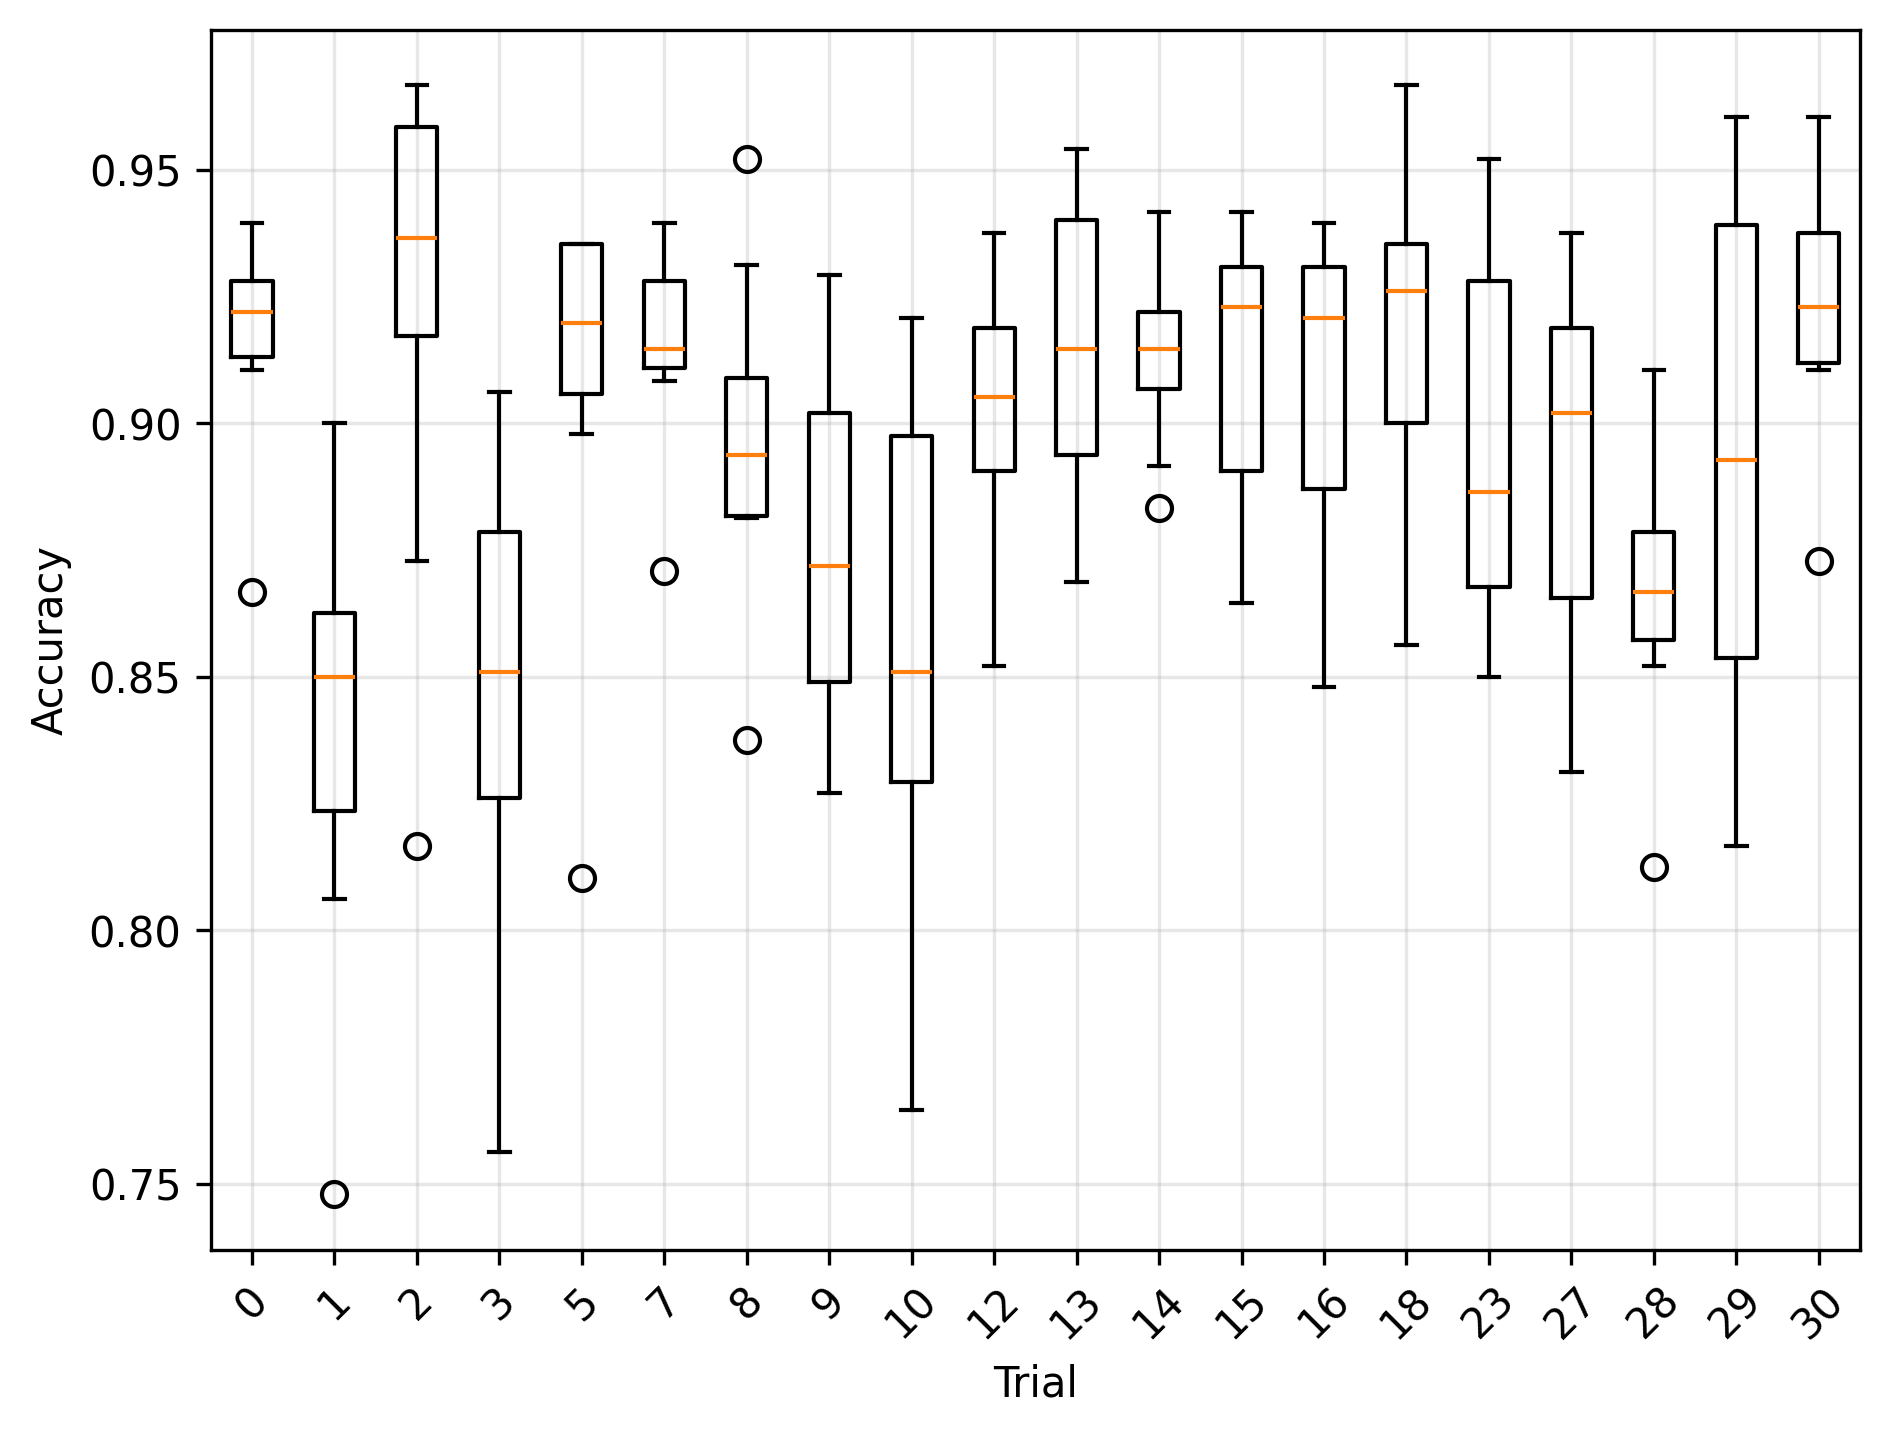

In [15]:
plt.boxplot(
    completed["user_attrs_accuracies"].apply(lambda x: list(x.values())),
    tick_labels=completed["number"].astype(int).tolist(),
)
plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.tick_params(axis="x", rotation=45)

### Accuracy vs IQR (best trials: top-left)

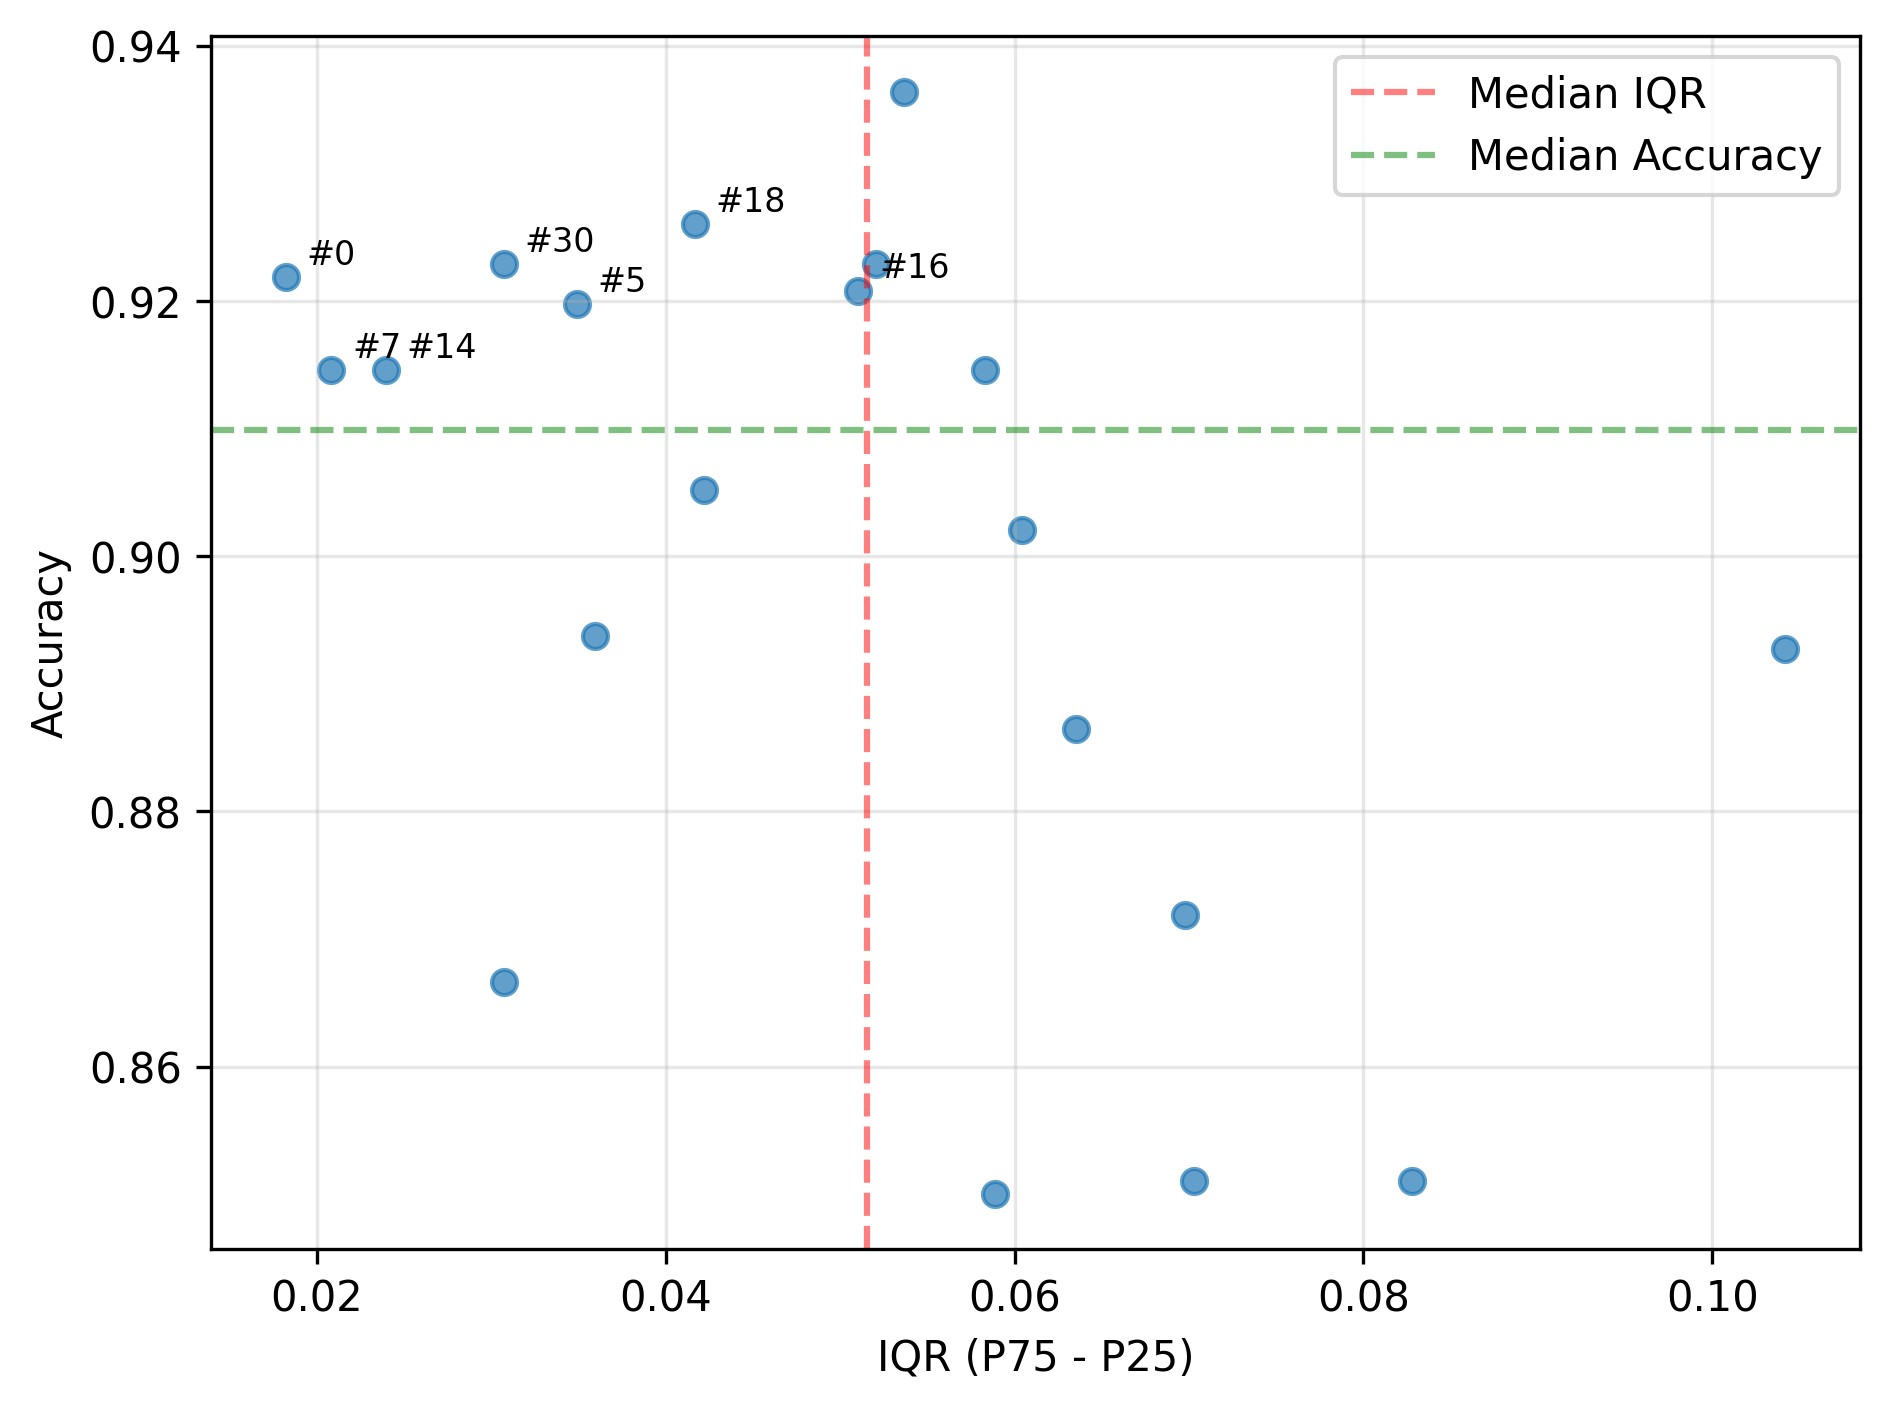

In [16]:
completed = study[study["state"] == "COMPLETE"].copy()
completed["iqr"] = completed["user_attrs_accuracy_p75"] - completed["user_attrs_accuracy_p25"]

sc = plt.scatter(completed["iqr"], completed["value"], alpha=0.7)
# annotate best trials (top-left quadrant)
thresh_iqr = completed["iqr"].median()
thresh_acc = completed["value"].median()
for _, row in completed[(completed["iqr"] < thresh_iqr) & (completed["value"] > thresh_acc)].iterrows():
    plt.annotate(
        f"#{int(row['number'])}",
        (row["iqr"], row["value"]),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=8,
    )
plt.axvline(thresh_iqr, color="red", linestyle="--", alpha=0.5, label="Median IQR")
plt.axhline(thresh_acc, color="green", linestyle="--", alpha=0.5, label="Median Accuracy")
plt.xlabel("IQR (P75 - P25)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()